https://www.kaggle.com/datasets/tatheerabbas/industrial-machine-predictive-maintenance?resource=download

In [16]:
import pandas as pd

df = pd.read_csv('predictive_maintenance_v3.csv')

df['timestamp'] = pd.to_datetime(df['timestamp'])
df['machine_id'] = df['machine_id'].astype('category')
df['failure_within_24h'] = df['failure_within_24h'].astype('category')

# Features like temp and rpm vary widely across machines, so we can normalize them for each machine separately
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

columns_to_scale = [
    'vibration_rms',
    'temperature_motor', 
    'current_phase_avg',
    'pressure_level',
    'rpm',
    'ambient_temp']

df[columns_to_scale] = df.groupby('machine_id', observed=True)[columns_to_scale].transform(
    lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).flatten()
)

print(df.info())

display(df.head(10))

# Print the column names
print(df.columns)

# Print unique machine ids
print(df['machine_id'].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24042 entries, 0 to 24041
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   timestamp                24042 non-null  datetime64[ns]
 1   machine_id               24042 non-null  category      
 2   machine_type             24042 non-null  object        
 3   vibration_rms            23042 non-null  float64       
 4   temperature_motor        23208 non-null  float64       
 5   current_phase_avg        23311 non-null  float64       
 6   pressure_level           23118 non-null  float64       
 7   rpm                      23509 non-null  float64       
 8   operating_mode           24042 non-null  object        
 9   hours_since_maintenance  24042 non-null  float64       
 10  ambient_temp             24042 non-null  float64       
 11  rul_hours                24042 non-null  float64       
 12  failure_within_24h       24042 n

,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
0,2024-01-01 00:00:00,1,CNC,-0.960921,-0.543510,-0.887565,-0.981032,-1.105958,idle,273.80,0.303077,61.00,0,none,0
1,2024-01-01 00:03:00,1,CNC,-1.004137,-1.531123,-0.852371,-0.981032,-1.070933,idle,273.85,-1.003816,60.95,0,none,0
2,2024-01-01 00:21:00,1,CNC,-1.032948,-0.522497,NaN,-1.061025,-1.104329,idle,274.15,0.197112,60.65,0,none,0
3,2024-01-01 00:45:00,1,CNC,-0.996934,-1.259059,-0.942117,-1.015811,-1.097360,idle,274.55,0.126470,60.25,0,none,0
4,2024-01-01 00:54:00,1,CNC,-0.910502,-1.441541,-1.003707,-1.029723,-1.086952,idle,274.70,-0.791887,60.10,0,none,0
5,2024-01-01 01:23:00,1,CNC,-0.867286,-1.374078,-0.945636,-0.981032,-1.112927,idle,275.18,1.080148,59.62,0,none,0
6,2024-01-01 01:47:00,1,CNC,-0.910502,-1.406150,-1.063537,-0.907995,-1.054642,idle,275.58,-0.791887,59.22,0,none,0
7,2024-01-01 01:55:00,1,CNC,0.566056,0.016100,-0.002425,0.910974,0.768569,normal,275.72,-0.579959,59.08,0,none,0
8,2024-01-01 01:59:00,1,CNC,-1.011340,-1.047823,-1.072336,-0.914951,-1.099441,idle,275.78,-0.509316,59.02,0,none,0
9,2024-01-01 02:12:00,1,CNC,-0.896096,-1.250212,-0.943876,-0.991466,-1.104148,idle,276.00,1.080148,58.80,0,none,0


Index(['timestamp', 'machine_id', 'machine_type', 'vibration_rms',
       'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm',
       'operating_mode', 'hours_since_maintenance', 'ambient_temp',
       'rul_hours', 'failure_within_24h', 'failure_type',
       'estimated_repair_cost'],
      dtype='object')
[1, 2, 3, 4, 5, ..., 16, 17, 18, 19, 20]
Length: 20
Categories (20, int64): [1, 2, 3, 4, ..., 17, 18, 19, 20]


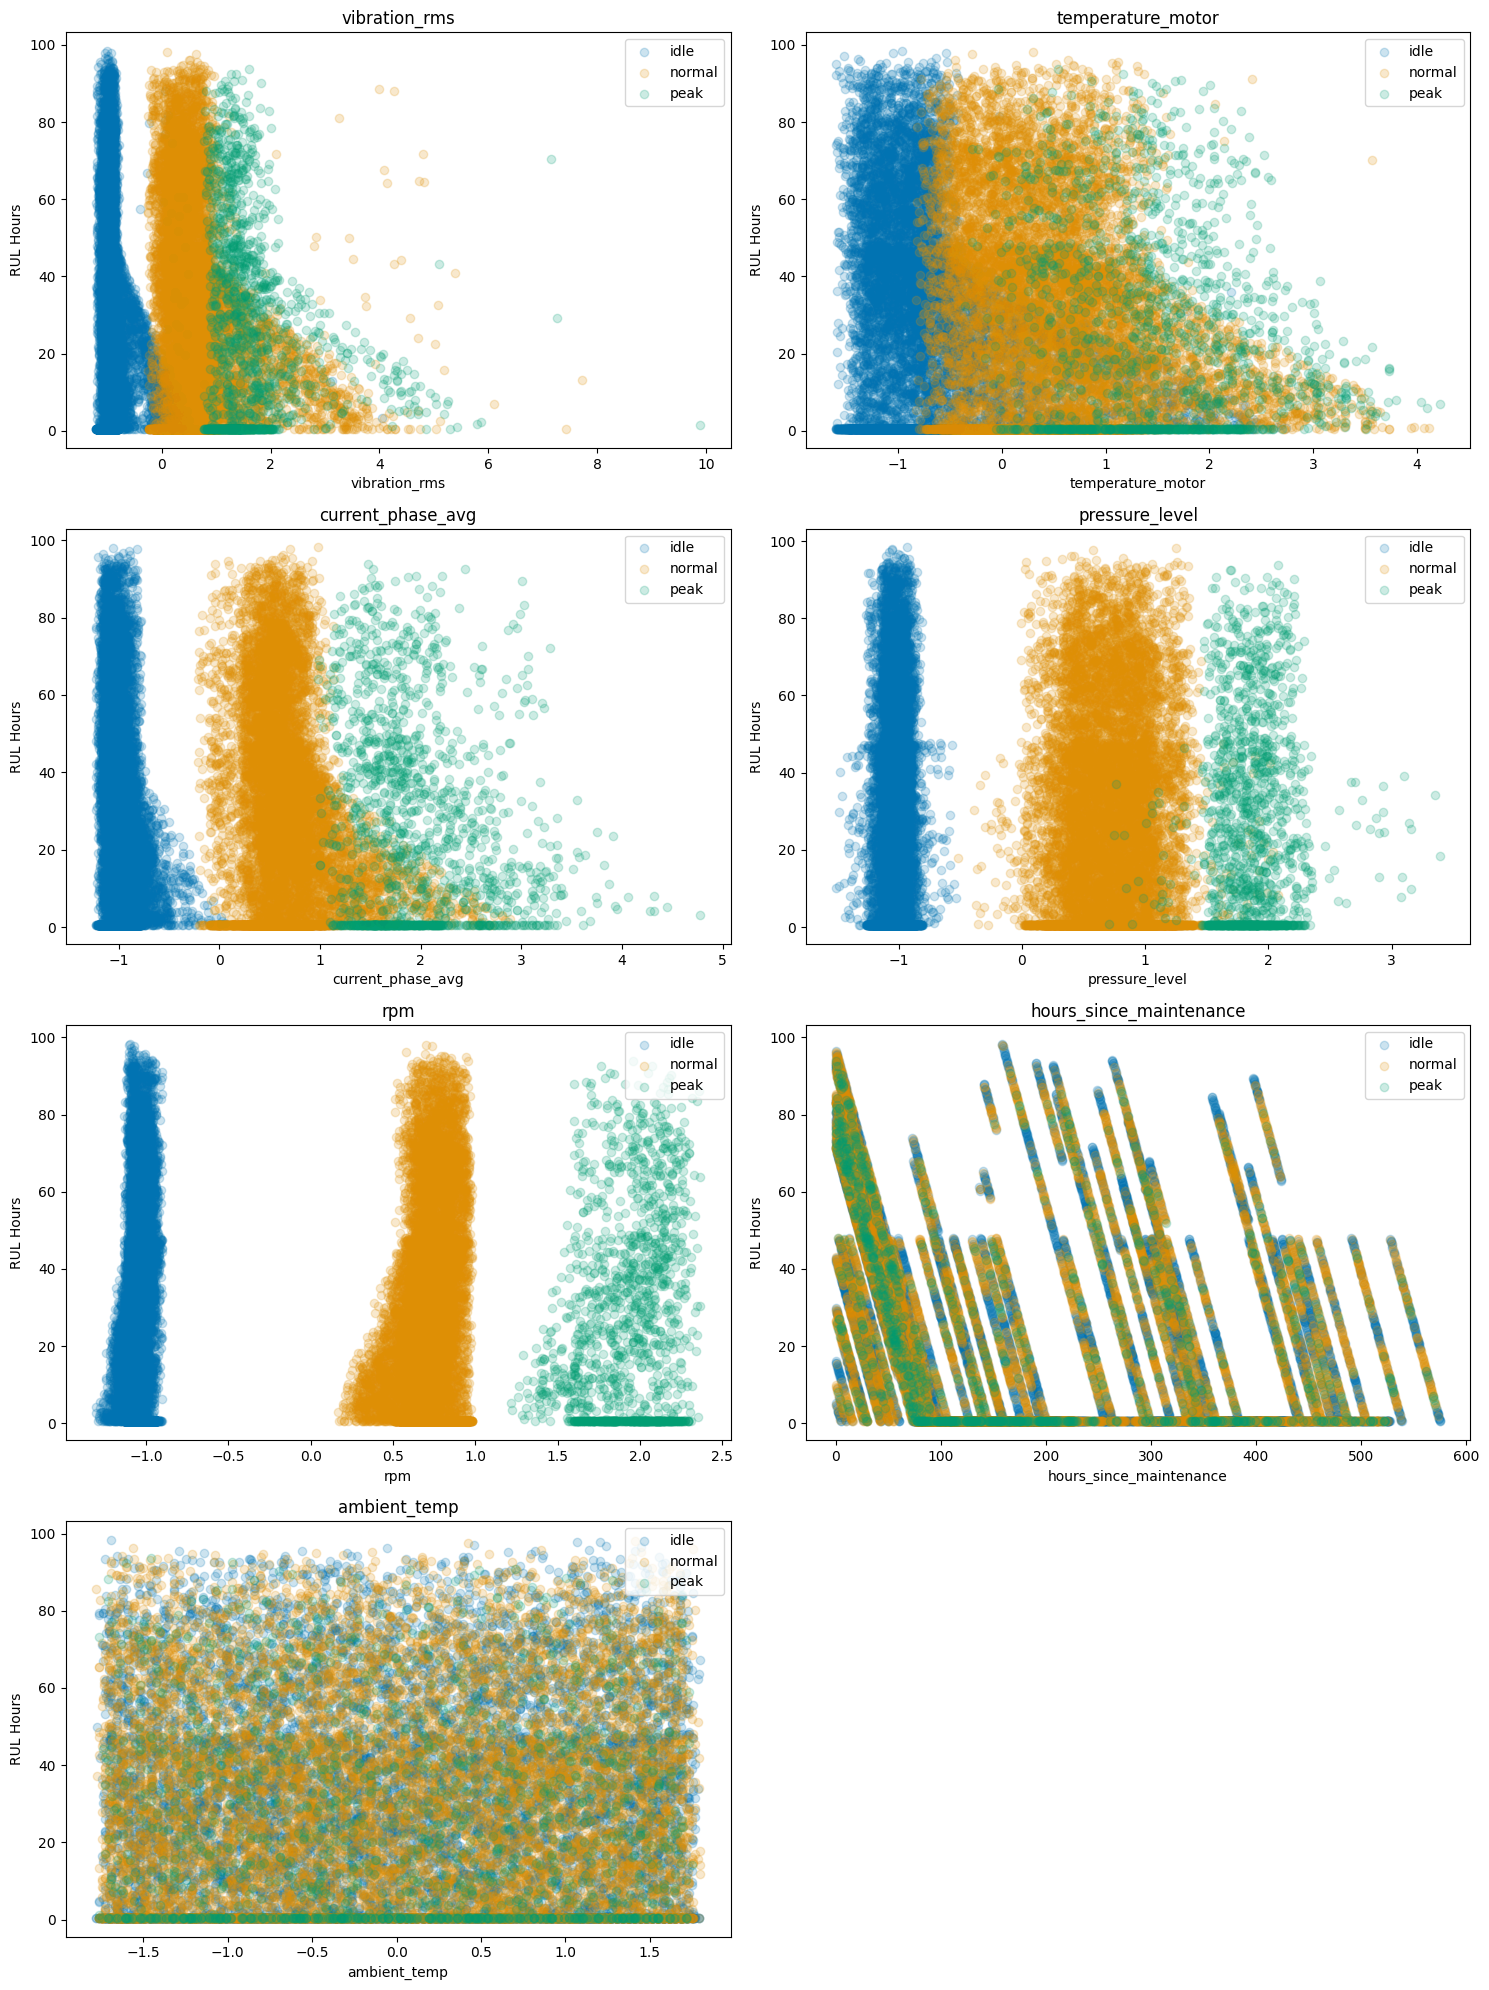

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

target_columns = ['rul_hours', 'failure_within_24h', 'estimated_repair_cost', 'failure_type']
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
numeric_cols = [col for col in numeric_cols if col not in target_columns]

# Color map for operating_mode using seaborn colorblind palette
modes = sorted(df['operating_mode'].unique())
palette = sns.color_palette("colorblind", n_colors=len(modes))
mode_colors = dict(zip(modes, palette))

# For all numeric columns, plot scatter plots against rul_hours as subplots
num_cols = 2
num_rows = (len(numeric_cols) + num_cols - 1) // num_cols
plt.figure(figsize=(15, num_rows * 5))

for i, col in enumerate(numeric_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    for mode in modes:
        subset = df[df['operating_mode'] == mode]
        plt.scatter(
            subset[col],
            subset['rul_hours'],
            alpha=0.2,
            label=mode,
            color=mode_colors[mode]
        )
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('RUL Hours')
    plt.legend()

plt.tight_layout()
plt.show()

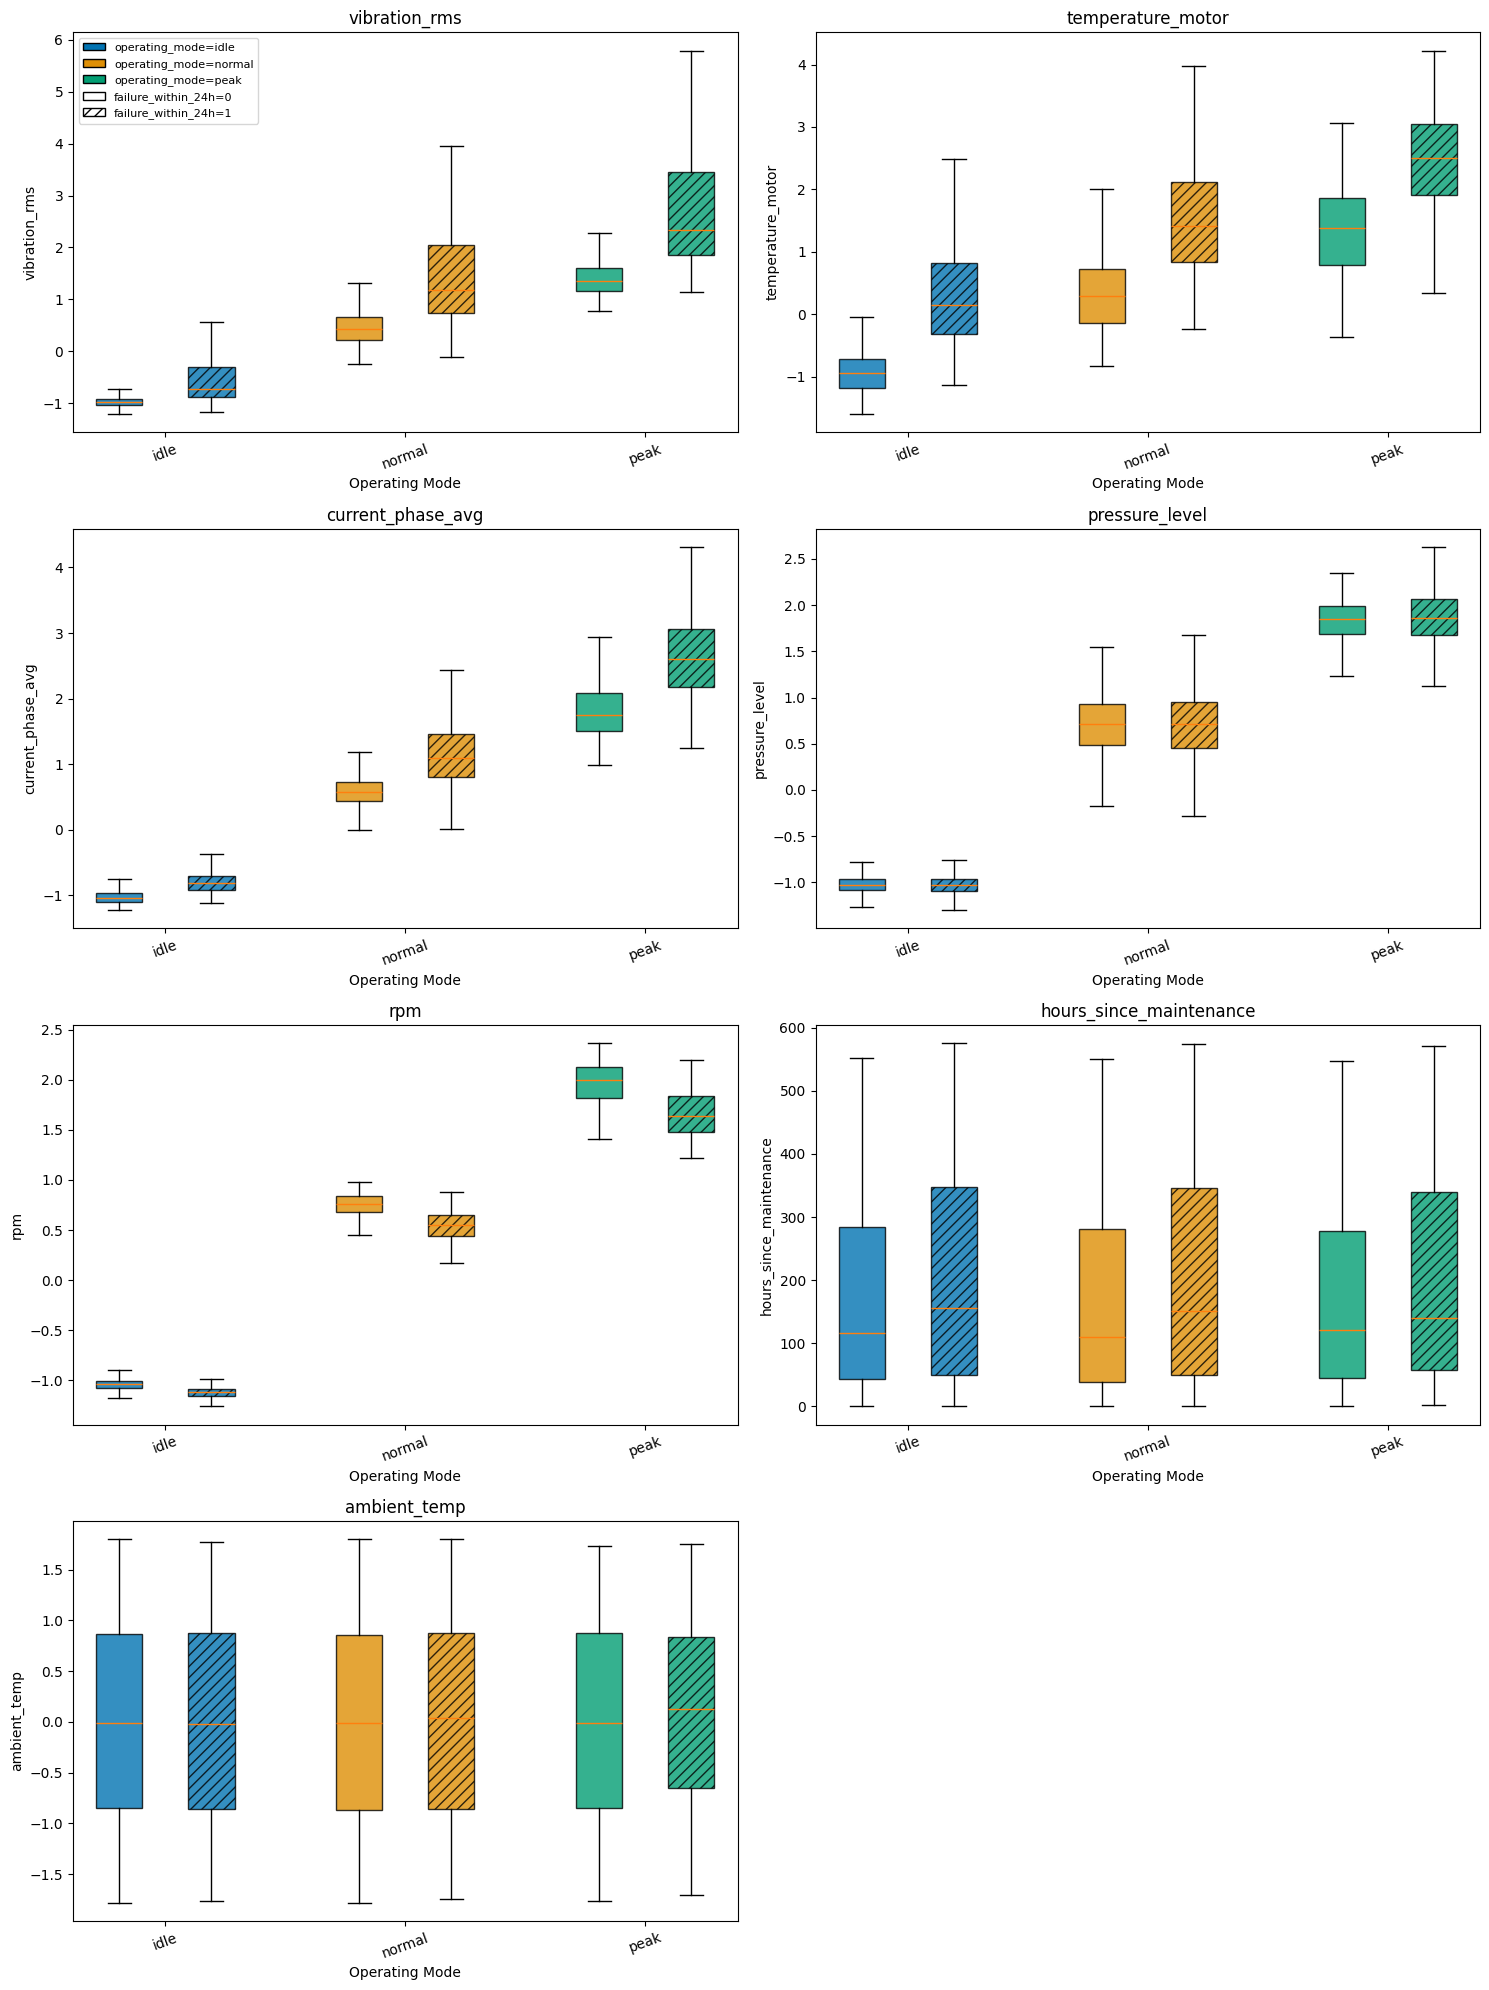

In [57]:
import matplotlib.patches as mpatches

# Box plots: color by operating_mode, hatch by failure_within_24h
num_cols = 2
num_rows = (len(numeric_cols) + num_cols - 1) // num_cols
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 5))
axes = axes.flatten()

modes = sorted(df['operating_mode'].unique())
failure_vals = sorted(df['failure_within_24h'].cat.categories.tolist())
palette = sns.color_palette("colorblind", n_colors=len(modes))
mode_colors = dict(zip(modes, palette))
hatch_styles = [None, '///', 'xxx', '\\\\\\']
hatch_map = {f: hatch_styles[i % len(hatch_styles)] for i, f in enumerate(failure_vals)}

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    data_to_plot = []
    positions = []
    style_meta = []

    pos = 1
    for mode in modes:
        for f in failure_vals:
            vals = df[(df['operating_mode'] == mode) & (df['failure_within_24h'] == f)][col].dropna()
            data_to_plot.append(vals if len(vals) > 0 else [float('nan')])
            positions.append(pos)
            style_meta.append((mode, f))
            pos += 1
        pos += 0.6  # gap between operating_mode groups

    bp = ax.boxplot(
        data_to_plot,
        positions=positions,
        widths=0.5,
        patch_artist=True,
        showfliers=False
    )

    for patch, (mode, f) in zip(bp['boxes'], style_meta):
        patch.set_facecolor(mode_colors[mode])
        patch.set_edgecolor('black')
        patch.set_hatch(hatch_map[f])
        patch.set_alpha(0.8)

    # Center x-ticks at each operating_mode group
    group_centers = []
    start = 1
    group_width = len(failure_vals)
    for _ in modes:
        group_centers.append(start + (group_width - 1) / 2)
        start += group_width + 0.6

    ax.set_xticks(group_centers)
    ax.set_xticklabels(modes, rotation=20)
    ax.set_title(col)
    ax.set_xlabel('Operating Mode')
    ax.set_ylabel(col)

    if i == 0:
        mode_legend = [
            mpatches.Patch(facecolor=mode_colors[m], edgecolor='black', label=f'operating_mode={m}')
            for m in modes
        ]
        failure_legend = [
            mpatches.Patch(facecolor='white', edgecolor='black', hatch=hatch_map[f], label=f'failure_within_24h={f}')
            for f in failure_vals
        ]
        ax.legend(handles=mode_legend + failure_legend, loc='best', fontsize=8)

# Hide any unused subplot axes
for j in range(len(numeric_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

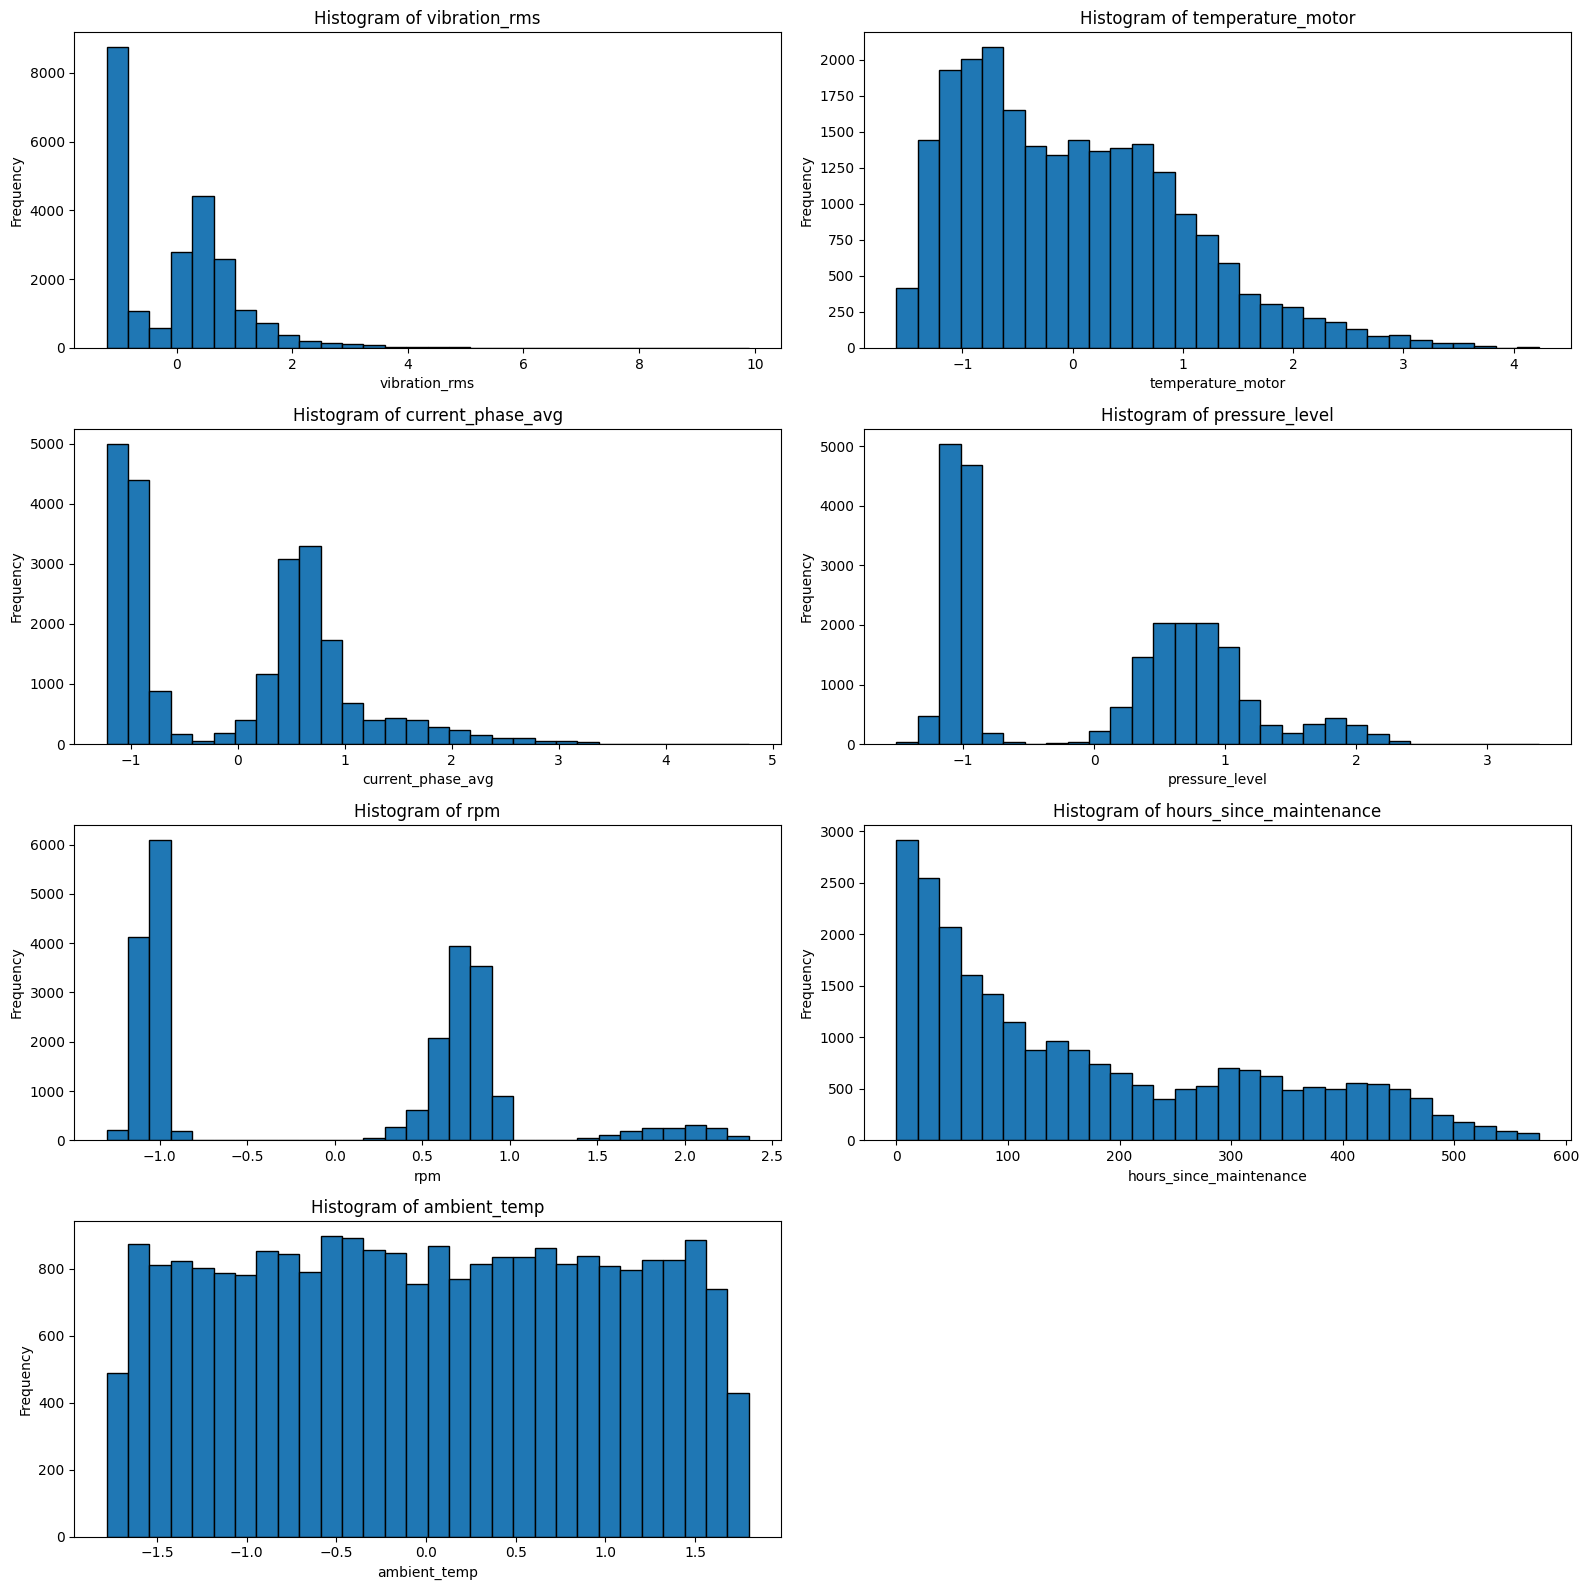

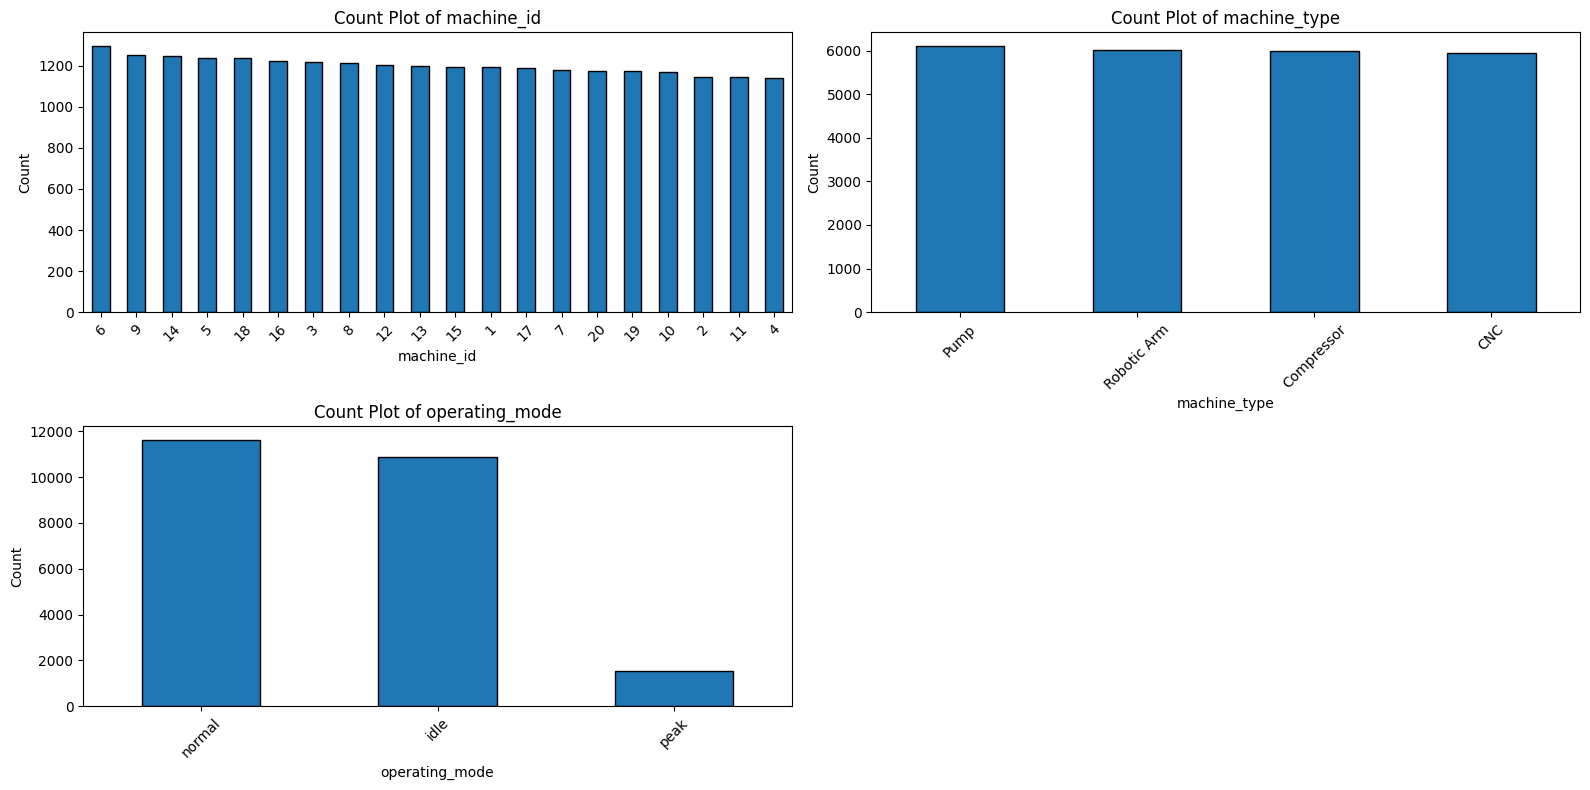

In [35]:
# Plot histograms for all numeric columns as a subplot
num_cols = len(numeric_cols)
cols = 2
rows = (num_cols + cols - 1) // cols
plt.figure(figsize=(16, 4 * rows))
for i, col in enumerate(numeric_cols):
    plt.subplot(rows, cols, i + 1)
    plt.hist(df[col], bins=30, edgecolor='k')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Plot count plots of all categorical columns as a subplot
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
# Remove any target columns from categorical_cols
categorical_cols = [col for col in categorical_cols if col not in target_columns]

num_cols = len(categorical_cols)
cols = 2
rows = (num_cols + cols - 1) // cols
plt.figure(figsize=(16, 4 * rows))
for i, col in enumerate(categorical_cols):
    plt.subplot(rows, cols, i + 1)
    df[col].value_counts().plot(kind='bar', edgecolor='k')
    plt.title(f'Count Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()